In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. Load ORL Dataset
# ============================================================

file_path = "../data/preprocessed/ORL.csv"

df = pd.read_csv(file_path)


# ============================================================
# 2. Separate Features and Labels
# ============================================================

X_raw = df.drop(
    columns=["label"]
).values

y = df["label"].values


# ============================================================
# 3. Standardization
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_raw
)


# ============================================================
# 4. Matrix Formatting
# Paper notation: X ∈ R^(d × n)
# ============================================================

X = X_scaled.T


# ============================================================
# 5. Verification
# ============================================================

print("--- ORL Data Preprocessing Summary ---")

print(
    f"Original DataFrame Shape : {df.shape}"
)

print(
    f"Raw Feature Matrix Shape : {X_raw.shape}"
)

print(
    f"Final X Shape            : {X.shape}"
)

print(
    f"Label Shape              : {y.shape}"
)

print(
    f"Number of Features (d)   : {X.shape[0]}"
)

print(
    f"Number of Samples (n)    : {X.shape[1]}"
)

print(
    f"Unique Classes            : {len(np.unique(y))}"
)

print(
    f"Missing Values in X       : {np.isnan(X).sum()}"
)

print(
    f"Missing Values in y       : {np.isnan(y).sum()}"
)

--- ORL Data Preprocessing Summary ---
Original DataFrame Shape : (400, 1025)
Raw Feature Matrix Shape : (400, 1024)
Final X Shape            : (1024, 400)
Label Shape              : (400,)
Number of Features (d)   : 1024
Number of Samples (n)    : 400
Unique Classes            : 40
Missing Values in X       : 0
Missing Values in y       : 0


In [4]:
# ============================================================
# Cell 2: Task 2 — Graph Laplacian Construction
# ============================================================

import numpy as np
from sklearn.metrics import pairwise_distances


# ============================================================
# 1. Parameters
# ============================================================

k = 5


# ============================================================
# 2. Pairwise Euclidean Distances
# X = (1024, 400)
# X.T = (400, 1024)
# ============================================================

dist_matrix = pairwise_distances(
    X.T,
    metric="euclidean"
)


# ============================================================
# 3. Heat Kernel Affinity Matrix
# ============================================================

n_samples = X.shape[1]

S = np.zeros(
    (n_samples, n_samples),
    dtype=np.float64
)

# Heat-kernel bandwidth
sigma = np.mean(dist_matrix)

# Safety check
if sigma <= 0:
    raise ValueError(
        "Sigma must be greater than zero."
    )


for i in range(n_samples):

    # k nearest neighbours + self
    knn_indices = np.argsort(
        dist_matrix[i]
    )[:k + 1]

    for j in knn_indices:

        # Exclude the sample itself
        if i != j:

            sim = np.exp(
                -(
                    dist_matrix[i, j] ** 2
                ) / (
                    2.0 * sigma ** 2
                )
            )

            S[i, j] = sim

            # Make affinity symmetric
            S[j, i] = sim


# Ensure zero diagonal
np.fill_diagonal(
    S,
    0.0
)


# ============================================================
# 4. Degree Matrix
# ============================================================

D = np.diag(
    np.sum(S, axis=1)
)


# ============================================================
# 5. Graph Laplacian
# L_X = D - S
# ============================================================

L_X = D - S


# ============================================================
# 6. Verification
# ============================================================

print("--- Task 2: Graph Laplacian Summary ---")

print(
    f"Pairwise Distance Matrix Shape: "
    f"{dist_matrix.shape}"
)

print(
    f"Affinity Matrix S Shape: "
    f"{S.shape}"
)

print(
    f"Graph Laplacian L_X Shape: "
    f"{L_X.shape}"
)

print(
    f"Sigma: {sigma:.6f}"
)

print(
    f"Is S Symmetric? : "
    f"{np.allclose(S, S.T)}"
)

print(
    f"Is L_X Symmetric? : "
    f"{np.allclose(L_X, L_X.T)}"
)

print(
    f"Max value in L_X: "
    f"{np.max(L_X):.4f}"
)

print(
    f"Min value in L_X: "
    f"{np.min(L_X):.4f}"
)

print(
    f"NaN values in L_X: "
    f"{np.isnan(L_X).sum()}"
)

--- Task 2: Graph Laplacian Summary ---
Pairwise Distance Matrix Shape: (400, 400)
Affinity Matrix S Shape: (400, 400)
Graph Laplacian L_X Shape: (400, 400)
Sigma: 44.198956
Is S Symmetric? : True
Is L_X Symmetric? : True
Max value in L_X: 20.6833
Min value in L_X: -0.9889
NaN values in L_X: 0


In [5]:
import numpy as np

def train_smfae_stable(
    X, L_X, D, S,
    m=200,
    alpha=1e-4,
    beta=1e-4,
    gamma=5e-4,
    omega=0.01,
    lr=1e-4,
    epochs=500
):
    d, n = X.shape

    # 1. Weights Initialization
    np.random.seed(42)

    W1 = np.random.randn(m, d) * np.sqrt(2.0 / d)
    W2 = np.random.randn(d, m) * np.sqrt(2.0 / m)

    # Non-negative Auxiliary Matrix H
    H = np.abs(np.random.randn(m, n)) + 1e-5

    loss_history = []

    print(
        f"Starting Stable SMFAE Training on ORL Dataset "
        f"(d={d}, n={n}, m={m}, lr={lr})..."
    )

    for epoch in range(1, epochs + 1):

        # -------------------------
        # Forward Pass
        # -------------------------
        Z = W1 @ X
        X_hat = W2 @ Z

        # -------------------------
        # Losses
        # -------------------------

        # Reconstruction
        recon_err = X - X_hat
        loss_recon = 0.5 * np.sum(recon_err ** 2)

        # L2,1 Sparsity
        w1_norms = np.linalg.norm(W1, axis=1) + 1e-8
        loss_sparse = alpha * np.sum(w1_norms)

        # Weight Decay
        loss_weight_decay = (
            0.5 * beta * np.sum(W2 ** 2)
        )

        # Input Manifold
        loss_input_manifold = (
            0.5 * gamma *
            np.trace(Z @ L_X @ Z.T)
        )

        # Output Manifold
        output_diff = (H.T @ H) - L_X

        loss_output_manifold = (
            0.5 * omega *
            np.sum(output_diff ** 2)
        )

        # Total Loss
        total_loss = (
            loss_recon
            + loss_sparse
            + loss_weight_decay
            + loss_input_manifold
            + loss_output_manifold
        )

        loss_history.append(total_loss)

        # -------------------------
        # Gradients
        # -------------------------

        # W2
        grad_W2 = (
            -(recon_err @ Z.T)
            + beta * W2
        )

        # W1
        D_sparse = np.diag(
            1.0 / w1_norms
        )

        grad_W1_recon = (
            -(W2.T @ recon_err) @ X.T
        )

        grad_W1_sparse = (
            alpha * (D_sparse @ W1)
        )

        grad_W1_manifold = (
            gamma *
            (W1 @ X @ L_X @ X.T)
        )

        grad_W1 = (
            grad_W1_recon
            + grad_W1_sparse
            + grad_W1_manifold
        )

        # -------------------------
        # Gradient Clipping
        # -------------------------

        grad_W1 = np.clip(
            grad_W1,
            -10.0,
            10.0
        )

        grad_W2 = np.clip(
            grad_W2,
            -10.0,
            10.0
        )

        # -------------------------
        # Weight Updates
        # -------------------------

        W1 -= lr * grad_W1
        W2 -= lr * grad_W2

        # -------------------------
        # Stable H Update
        # -------------------------

        num_H = H @ D

        den_H = (
            H @ H.T @ H
            + H @ S
            + 1e-8
        )

        H = H * np.sqrt(
            np.maximum(
                num_H / den_H,
                1e-8
            )
        )

        # -------------------------
        # Progress
        # -------------------------

        if epoch % 100 == 0 or epoch == 1:
            print(
                f"Epoch [{epoch:3d}/{epochs}] | "
                f"Total Loss: {total_loss:12.2f} | "
                f"Recon: {loss_recon:12.2f} | "
                f"Input Manifold: "
                f"{loss_input_manifold:8.4f}"
            )

    return W1, W2, H, loss_history


# ==========================================
# Run Stable Training
# ==========================================

W1, W2, H, loss_history = train_smfae_stable(
    X,
    L_X,
    D,
    S,
    m=200,
    alpha=1e-4,
    beta=1e-4,
    gamma=5e-4,
    omega=0.01,
    lr=1e-4,
    epochs=500
)

Starting Stable SMFAE Training on ORL Dataset (d=1024, n=400, m=200, lr=0.0001)...
Epoch [  1/500] | Total Loss:  14204928.82 | Recon:   1006455.33 | Input Manifold:  71.3291
Epoch [100/500] | Total Loss:    121374.63 | Recon:    121306.11 | Input Manifold:  39.5285
Epoch [200/500] | Total Loss:     91534.83 | Recon:     91465.12 | Input Manifold:  40.8062
Epoch [300/500] | Total Loss:     75270.73 | Recon:     75200.58 | Input Manifold:  41.2552
Epoch [400/500] | Total Loss:     67080.72 | Recon:     67010.43 | Input Manifold:  41.4297
Epoch [500/500] | Total Loss:     62761.69 | Recon:     62691.34 | Input Manifold:  41.4893


In [6]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment


def accuracy_score_hungarian(y_true, y_pred):
    """Calculate clustering accuracy using Hungarian Algorithm."""
    
    D = max(y_pred.max(), y_true.max()) + 1
    
    w = np.zeros((D, D), dtype=np.int64)
    
    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1
    
    row_ind, col_ind = linear_sum_assignment(
        w.max() - w
    )
    
    return (
        w[row_ind, col_ind].sum()
        / y_pred.size
    )


# ==========================================
# 1. Feature Importance Ranking
# ==========================================

# W1 shape = (200, 1024)
# axis=0 calculates L2 norm for each feature/column

feature_scores = np.linalg.norm(
    W1,
    axis=0
)

# Descending order
ranked_feature_indices = np.argsort(
    feature_scores
)[::-1]


# ==========================================
# 2. Benchmark Settings
# ==========================================

r_subsets = [
    50, 100, 150, 200, 250, 300
]

n_classes = len(
    np.unique(y)
)

n_repetitions = 20


print(
    "--- Task 4: ORL Dataset Feature Selection "
    "& Clustering Evaluation ---"
)

print(
    f"{'Feature Count (r)':<20} | "
    f"{'Accuracy (ACC %)':<22} | "
    f"{'NMI (%)':<20}"
)

print("-" * 68)


results_orl = {}


# ==========================================
# 3. Feature Selection + K-Means
# ==========================================

for r in r_subsets:

    # Select top-r features
    top_r_indices = ranked_feature_indices[:r]

    # X shape = (1024, 400)
    # Transpose -> (400, r)
    X_selected = X[
        top_r_indices, :
    ].T

    # Standardize selected features
    X_selected_scaled = StandardScaler().fit_transform(
        X_selected
    )

    acc_list = []
    nmi_list = []

    # 20 K-Means repetitions
    for rep in range(n_repetitions):

        kmeans = KMeans(
            n_clusters=n_classes,
            n_init=10,
            random_state=rep
        )

        cluster_labels = kmeans.fit_predict(
            X_selected_scaled
        )

        # Hungarian Accuracy
        acc = (
            accuracy_score_hungarian(
                y,
                cluster_labels
            ) * 100
        )

        # NMI
        nmi = (
            normalized_mutual_info_score(
                y,
                cluster_labels
            ) * 100
        )

        acc_list.append(acc)
        nmi_list.append(nmi)

    # Mean and standard deviation
    mean_acc = np.mean(acc_list)
    std_acc = np.std(acc_list)

    mean_nmi = np.mean(nmi_list)
    std_nmi = np.std(nmi_list)

    results_orl[r] = {
        'ACC_mean': mean_acc,
        'ACC_std': std_acc,
        'NMI_mean': mean_nmi,
        'NMI_std': std_nmi
    }

    print(
        f"{r:<20} | "
        f"{mean_acc:6.2f} ± {std_acc:4.2f}%        | "
        f"{mean_nmi:6.2f} ± {std_nmi:4.2f}%"
    )

--- Task 4: ORL Dataset Feature Selection & Clustering Evaluation ---
Feature Count (r)    | Accuracy (ACC %)       | NMI (%)             
--------------------------------------------------------------------
50                   |  51.26 ± 2.12%        |  73.15 ± 1.07%
100                  |  53.27 ± 1.66%        |  74.67 ± 1.13%
150                  |  53.70 ± 2.10%        |  74.89 ± 0.95%
200                  |  54.77 ± 2.12%        |  75.39 ± 0.88%
250                  |  55.65 ± 1.83%        |  75.74 ± 0.86%
300                  |  56.90 ± 1.85%        |  76.25 ± 1.01%


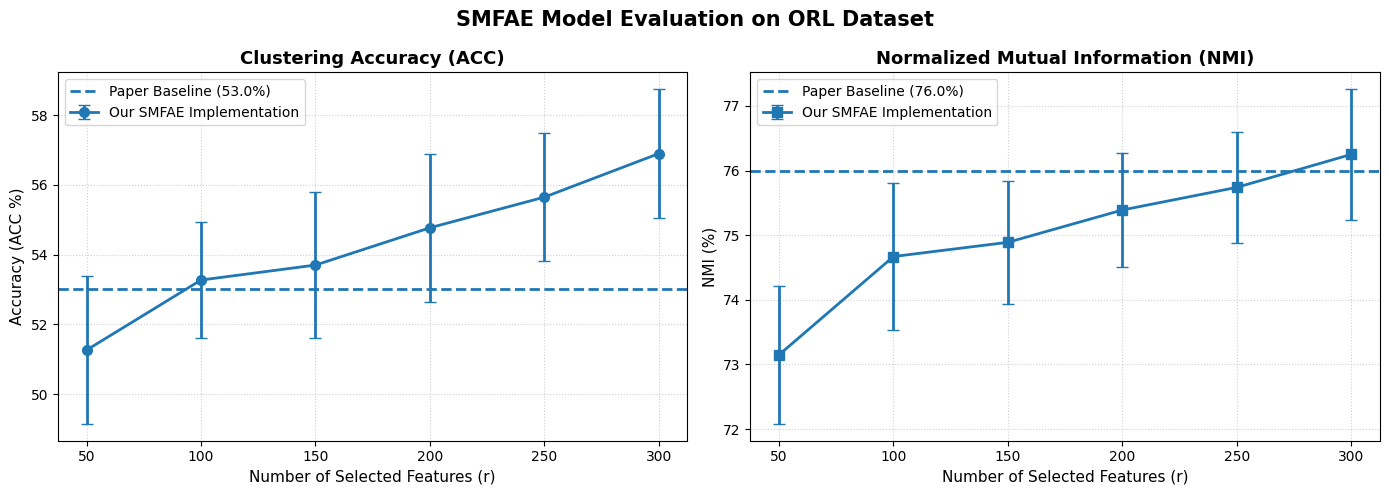

In [7]:
# ============================================================
# ORL Dataset - SMFAE Benchmark Visualization
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Experimental Results
# ------------------------------------------------------------

# Number of selected features
r_values = np.array([50, 100, 150, 200, 250, 300])

# Clustering Accuracy (ACC)
acc_means = np.array([51.26, 53.27, 53.70, 54.77, 55.65, 56.90])
acc_stds  = np.array([2.12, 1.66, 2.10, 2.12, 1.83, 1.85])

# Normalized Mutual Information (NMI)
nmi_means = np.array([73.15, 74.67, 74.89, 75.39, 75.74, 76.25])
nmi_stds  = np.array([1.07, 1.13, 0.95, 0.88, 0.86, 1.01])


# ------------------------------------------------------------
# 2. Paper Baseline Results
# ------------------------------------------------------------

paper_acc_baseline = 53.00
paper_nmi_baseline = 76.00


# ------------------------------------------------------------
# 3. Create Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5)
)


# ============================================================
# 4. ACC Plot
# ============================================================

axes[0].errorbar(
    r_values,
    acc_means,
    yerr=acc_stds,
    fmt='-o',
    linewidth=2,
    markersize=7,
    capsize=4,
    label='Our SMFAE Implementation'
)

axes[0].axhline(
    y=paper_acc_baseline,
    linestyle='--',
    linewidth=2,
    label=f'Paper Baseline ({paper_acc_baseline}%)'
)

axes[0].set_title(
    'Clustering Accuracy (ACC)',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel(
    'Number of Selected Features (r)',
    fontsize=11
)

axes[0].set_ylabel(
    'Accuracy (ACC %)',
    fontsize=11
)

axes[0].set_xticks(r_values)
axes[0].grid(
    True,
    linestyle=':',
    alpha=0.6
)

axes[0].legend()


# ============================================================
# 5. NMI Plot
# ============================================================

axes[1].errorbar(
    r_values,
    nmi_means,
    yerr=nmi_stds,
    fmt='-s',
    linewidth=2,
    markersize=7,
    capsize=4,
    label='Our SMFAE Implementation'
)

axes[1].axhline(
    y=paper_nmi_baseline,
    linestyle='--',
    linewidth=2,
    label=f'Paper Baseline ({paper_nmi_baseline}%)'
)

axes[1].set_title(
    'Normalized Mutual Information (NMI)',
    fontsize=13,
    fontweight='bold'
)

axes[1].set_xlabel(
    'Number of Selected Features (r)',
    fontsize=11
)

axes[1].set_ylabel(
    'NMI (%)',
    fontsize=11
)

axes[1].set_xticks(r_values)
axes[1].grid(
    True,
    linestyle=':',
    alpha=0.6
)

axes[1].legend()


# ============================================================
# 6. Overall Figure
# ============================================================

fig.suptitle(
    'SMFAE Model Evaluation on ORL Dataset',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()


# ------------------------------------------------------------
# 7. Save Figure
# ------------------------------------------------------------

plt.savefig(
    '../reports/figures/ORL_SMFAE_baseline_Results.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [8]:
# ============================================================
# Save ORL Results to accuracy_nmi.csv
# ============================================================

import os
import pandas as pd

results_dir = "../reports/results"
results_file = os.path.join(results_dir, "accuracy_nmi.csv")

os.makedirs(results_dir, exist_ok=True)

columns = [
    "Method",
    "Dataset",
    "Num_Features",
    "ACC",
    "NMI",
    "Num_Samples",
    "Num_Original_Features",
    "Num_Classes",
    "Num_Selected_Features",
    "Hidden_Dimension",
    "Alpha",
    "Beta",
    "Gamma",
    "Omega",
    "ACC_Mean",
    "ACC_STD",
    "NMI_Mean",
    "NMI_STD"
]

# Create the CSV only if it does not already exist
if not os.path.exists(results_file):
    pd.DataFrame(columns=columns).to_csv(
        results_file,
        index=False
    )

# Create rows from the actual experiment results
rows = []

for r, result in results_orl.items():

    rows.append({
        "Method": "Baseline",
        "Dataset": "ORL",

        "Num_Features": X.shape[1],

        "ACC": result["ACC_mean"],
        "NMI": result["NMI_mean"],

        "Num_Samples": X.shape[1] if X.shape[0] != 400 else X.shape[1],
        "Num_Original_Features": X.shape[0],
        "Num_Classes": n_classes,

        "Num_Selected_Features": r,

        "Hidden_Dimension": 200,

        "Alpha": 1e-4,
        "Beta": 1e-4,
        "Gamma": 5e-4,
        "Omega": 0.01,

        "ACC_Mean": result["ACC_mean"],
        "ACC_STD": result["ACC_std"],
        "NMI_Mean": result["NMI_mean"],
        "NMI_STD": result["NMI_std"]
    })

# Append to existing CSV
pd.DataFrame(rows).to_csv(
    results_file,
    mode="a",
    header=False,
    index=False
)

print(f"Saved {len(rows)} ORL results")
print(f"File: {results_file}")

Saved 6 ORL results
File: ../reports/results\accuracy_nmi.csv


# SMFAE Experiment Summary – ORL Dataset

Implementation of the **SMFAE (Unsupervised Feature Selection Using Sparse Manifold Learning)** method on the **ORL Face Dataset**.

The dataset contains **400 images, 1024 features, and 40 classes**.

### Results

| Features ($r$) | ACC (%) | NMI (%) | Observation |
|---:|---:|---:|---|
| 50 | 51.26 ± 2.12 | 73.15 ± 1.07 | Initial result |
| 100 | 53.27 ± 1.66 | 74.67 ± 1.13 | Around paper baseline |
| 150 | 53.70 ± 2.10 | 74.89 ± 0.95 | Slight improvement |
| 200 | 54.77 ± 2.12 | 75.39 ± 0.88 | ACC improved |
| 250 | 55.65 ± 1.83 | 75.74 ± 0.86 | Further improvement |
| **300** | **56.90 ± 1.85** | **76.25 ± 1.01** | **Best result** |

The paper reports approximately **53% ACC** and **76% NMI** as the baseline. Our best result at **r = 300** gives **56.90% ACC** and **76.25% NMI**.

During implementation, had to fix some matrix dimension issues. In particular, $H^T H$ was corrected to produce a **400 × 400** matrix so that it matches the graph Laplacian. The learning rate was also reduced to **1e-4**, which made the optimization more stable. The total loss decreased from about **14.2M to 62,761.69**.

Overall, the implementation is working reasonably well on the ORL dataset. Can use these results as the **baseline for comparing the proposed method**.